**RFM Analysis**

In [1]:
# Import the Pandas library for data manipulation and analysis
import pandas as pd

# Load the UK retail dataset and automatically convert InvoiceDate to datetime format
df = pd.read_csv("Data/uk_retail.csv", parse_dates=["InvoiceDate"])

In [2]:
# Set the reference date as one day after the most recent transaction date
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Display the reference date
print(reference_date)

2011-12-10 12:49:00


**Build RFM Table**

In [3]:
# Calculate RFM metrics (Recency, Frequency, Monetary) for each customer
rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12608.0      405          1    415.79
2      12745.0      487          2    723.85
3      12746.0      541          1    254.55
4      12747.0        2         26   9276.54


In [4]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5353.000000,5353.000000,5353.000000,5353.000000
mean,15556.524566,203.138240,6.266766,2750.447883
std,1581.187812,210.106131,11.998015,12077.255964
min,12346.000000,1.000000,1.000000,0.000000
25%,14190.000000,26.000000,1.000000,335.520000
50%,15564.000000,99.000000,3.000000,848.710000
75%,16922.000000,382.000000,7.000000,2212.280000
max,18287.000000,739.000000,337.000000,608821.650000


In [5]:
# Assign RFM scores (1–5) to customers based on Recency, Frequency, and Monetary values
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5, labels=[5,4,3,2,1])

# Score customers based on purchase frequency (higher frequency = higher score)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=[1,2,3,4,5])

# Score customers based on total spending (higher spending = higher score)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=5, labels=[1,2,3,4,5])

# Combine the three scores into a single RFM score
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

# Display the first few rows of the scored customer dataset
print(rfm.head())

   Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0      12346.0      326         12  77556.46       2       5       5       255
1      12608.0      405          1    415.79       2       1       2       212
2      12745.0      487          2    723.85       1       2       3       123
3      12746.0      541          1    254.55       1       1       1       111
4      12747.0        2         26   9276.54       5       5       5       555


In [6]:
# Define a function to assign customer segments based on RFM scores
def segment_customer(row):
    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    # Customers who purchased recently and buy frequently
    if r >= 4 and f >= 4:
        return "Champion"

    # Customers with good recency and frequency
    elif r >= 3 and f >= 3:
        return "Loyal"

    # Recent customers with low purchase frequency
    elif r >= 4 and f <= 2:
        return "New Customer"

    # Previously active customers who have not purchased recently
    elif r <= 2 and f >= 3:
        return "At Risk"

    # Customers with low recency and low frequency
    elif r <= 2 and f <= 2:
        return "Lost"

    # Customers who do not fit the above categories
    else:
        return "Needs Attention"

# Apply the segmentation function to each customer
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

# Display the number of customers in each segment
print(rfm["Segment"].value_counts())

Segment
Lost               1395
Champion           1361
Loyal              1110
At Risk             741
New Customer        402
Needs Attention     344
Name: count, dtype: int64


C:\Users\Dell\AppData\Local\Temp\ipykernel_3436\885584043.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="Set2")


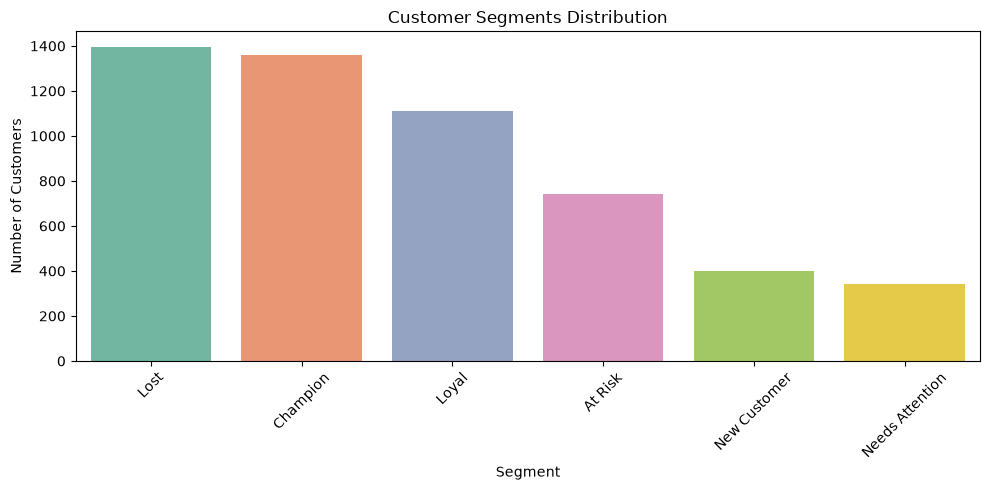

In [7]:
# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of customers in each segment
segment_counts = rfm["Segment"].value_counts()

# Create a bar chart showing the distribution of customer segments
plt.figure(figsize=(10,5))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="Set2")

# Add chart title and axis labels
plt.title("Customer Segments Distribution")
plt.ylabel("Number of Customers")
plt.xlabel("Segment")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent overlapping labels
plt.tight_layout()

# Display the chart
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_3436\2889790851.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_revenue.index, y=segment_revenue.values, palette="Set1")


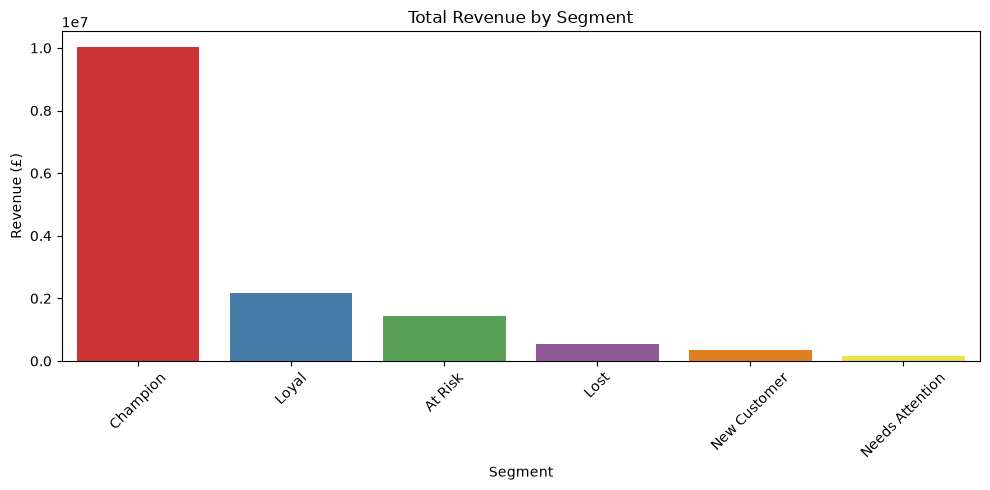

In [8]:
# Calculate the total revenue generated by each customer segment
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

# Create a bar chart to compare revenue contribution across segments
plt.figure(figsize=(10,5))
sns.barplot(x=segment_revenue.index, y=segment_revenue.values, palette="Set1")

# Add chart title and axis labels
plt.title("Total Revenue by Segment")
plt.ylabel("Revenue (£)")
plt.xlabel("Segment")

# Rotate segment labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent overlapping labels
plt.tight_layout()

# Display the chart
plt.show()

In [9]:
# Save the customer RFM segmentation results to a CSV file without including the DataFrame index
rfm.to_csv("Data/rfm_segments.csv", index=False)

# Display a confirmation message after successfully saving the file
print("Saved!")

Saved!
